In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [3]:
import pandas as pd
df = pd.read_csv('/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

In [4]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [6]:
df = df.drop_duplicates()
df.shape

(49582, 2)

In [7]:
df['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [8]:
#random each 2,500
n = 2500
df = (
    df.groupby('sentiment', group_keys=False)
      .apply(lambda x: x.sample(n=n, random_state=42))
      .reset_index(drop=True)
)

/tmp/ipykernel_37/887096898.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=n, random_state=42))


In [9]:
df['sentiment'].value_counts()

sentiment
negative    2500
positive    2500
Name: count, dtype: int64

In [10]:
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [11]:
# POS Mapper
from nltk import word_tokenize, pos_tag
from nltk.corpus import stopwords, wordnet
def get_wordnet_pos(word):
    tag = pos_tag([word])[0][1][0].upper()
    tag_dict = {
        'J': wordnet.ADJ,
        'N': wordnet.NOUN,
        'V': wordnet.VERB,
        'R': wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)

In [12]:
import re
from bs4 import BeautifulSoup
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Remove HTML tags
    soup = BeautifulSoup(text, 'lxml')
    text = soup.get_text(separator=' ')

    # Remove URLS
    text = re.sub(r'http\S+|www\S+|https\S+','',text)

    # Word Tokenization
    tokens = word_tokenize(text.lower())

    # Remove stopwords + non-alphabetic + Lemmatize with POS
    tokens = [
        lemmatizer.lemmatize(w, get_wordnet_pos(w))
        for w in tokens if w.isalpha() and w not in stop_words
        ]

    # Join the tokens back into a string
    return ' '.join(tokens)

In [13]:
df['cleaned_review'] = df['review'].apply(preprocess_text)

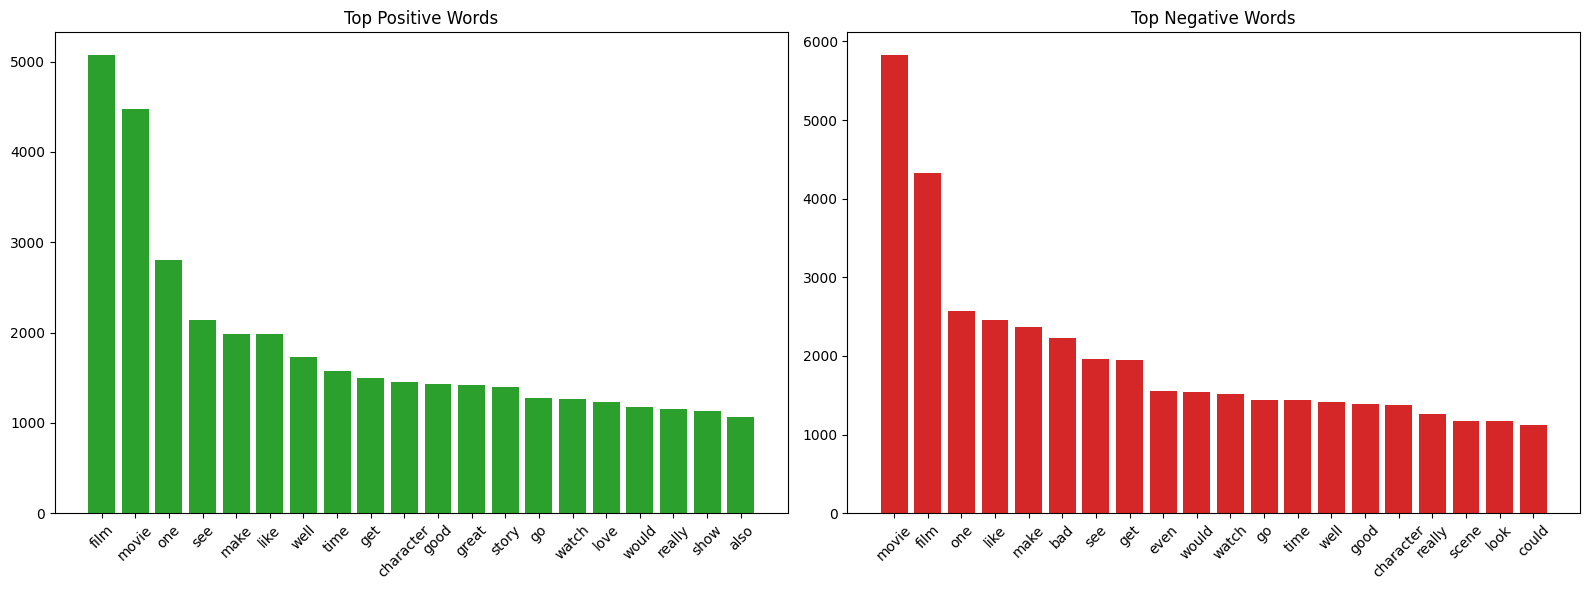

In [17]:
from collections import Counter
import matplotlib.pyplot as plt

positive_words = ' '.join(df[df['sentiment']=='positive']['cleaned_review'])
negative_words = ' '.join(df[df['sentiment']=='negative']['cleaned_review'])

def get_common_words(text, n):
    words = text.split()
    counter = Counter(words)
    return counter.most_common(n)

n = 20
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive
pos_common = get_common_words(positive_words, n)
pos_words, pos_counts = zip(*pos_common)
axes[0].bar(pos_words, pos_counts, color='#2ca02c')
axes[0].set_title('Top Positive Words')
axes[0].tick_params(axis='x', rotation=45)

# Negative
neg_common = get_common_words(negative_words, n)
neg_words, neg_counts = zip(*neg_common)
axes[1].bar(neg_words, neg_counts, color='#d62728')
axes[1].set_title('Top Negative Words')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


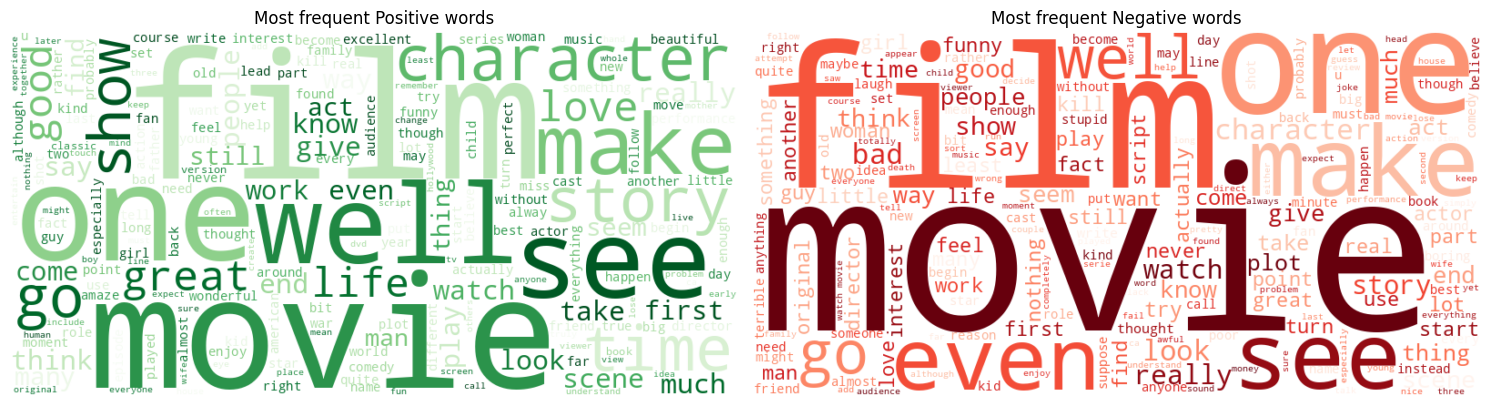

In [18]:
# Visualize the most frequent words per category using word clouds
from wordcloud import WordCloud
positive_WordCloud = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_words)
negative_WordCloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_words)

plt.figure(figsize=(15,10))

plt.subplot(1,2,1)
plt.imshow(positive_WordCloud, interpolation='bilinear')
plt.title('Most frequent Positive words')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(negative_WordCloud, interpolation='bilinear')
plt.title('Most frequent Negative words')
plt.axis('off')

plt.tight_layout()
plt.show()

In [20]:
# Train-Test Split 
from sklearn.model_selection import train_test_split
X = df['cleaned_review'] 
y = df['sentiment'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23, stratify=y)

In [21]:
print("Train set:")
print(y_train.value_counts(normalize=True) * 100)
print("\nTest set:")
print(y_test.value_counts(normalize=True) * 100)

Train set:
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64

Test set:
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
# Set Pipeline
pipe = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(solver='saga', max_iter=1000, random_state=23))
])

# Grid
param_grid = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__max_df': [0.7, 0.8, 0.9],
    'tfidf__min_df': [3, 5],
    'clf__C': [0.1, 1, 10],
    'clf__penalty': ['l2'],
}

# Create GridSearch
grid = GridSearchCV(pipe, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)

# Train Model
grid.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('clf',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=23,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10], 'clf__penalty': ['l2'],
                         'tfidf__max_df': [0.7, 0.8, 0.9],
                         'tfidf__min_df': [3, 5],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='accuracy', verbose=2)

In [23]:
# Predict Test Set
y_pred = grid.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report (precision, recall, f1-score)
from sklearn.metrics import classification_report
print("Classification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.863
Classification Report:
               precision    recall  f1-score   support

    negative       0.88      0.84      0.86       500
    positive       0.85      0.88      0.87       500

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



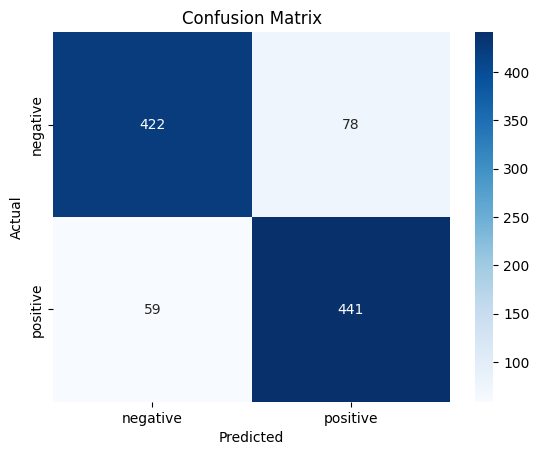

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=grid.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=grid.classes_, yticklabels=grid.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [25]:
import numpy as np
feature_names = grid.best_estimator_.named_steps['tfidf'].get_feature_names_out()
coefficients = grid.best_estimator_.named_steps['clf'].coef_[0]

# show top positive & top negative
top_positive = np.argsort(coefficients)[-10:]
top_negative = np.argsort(coefficients)[:10]

print("Top positive words:", feature_names[top_positive])
print("Top negative words:", feature_names[top_negative])


Top positive words: ['enjoy' 'entertain' 'perfect' 'amaze' 'definitely' 'performance' 'love'
 'best' 'excellent' 'great']
Top negative words: ['bad' 'waste' 'nothing' 'poor' 'terrible' 'boring' 'awful' 'suppose'
 'dull' 'stupid']


In [27]:
predictions = grid.predict(["I love Her."]) 
print(predictions)

['positive']


In [28]:
import joblib

joblib.dump(grid.best_estimator_, 'sentiment_model.pkl')

['sentiment_model.pkl']

In [29]:
model = joblib.load('sentiment_model.pkl')
pred = model.predict(["The best movie"])
print(pred)

['positive']
